--- Conflict Report ---
Repos with ≥1 conflict: 9 | Total conflicts: 0
Repos with ≥5 conflicts: 4

--- Company-wise Conflict Report ---
google: Attempts (repos) = 26 | Repos with ≥1 conflict = 6 | Repos with ≥5 conflicts = 2 | Total conflicts = 0
microsoft: Attempts (repos) = 62 | Repos with ≥1 conflict = 3 | Repos with ≥5 conflicts = 2 | Total conflicts = 0


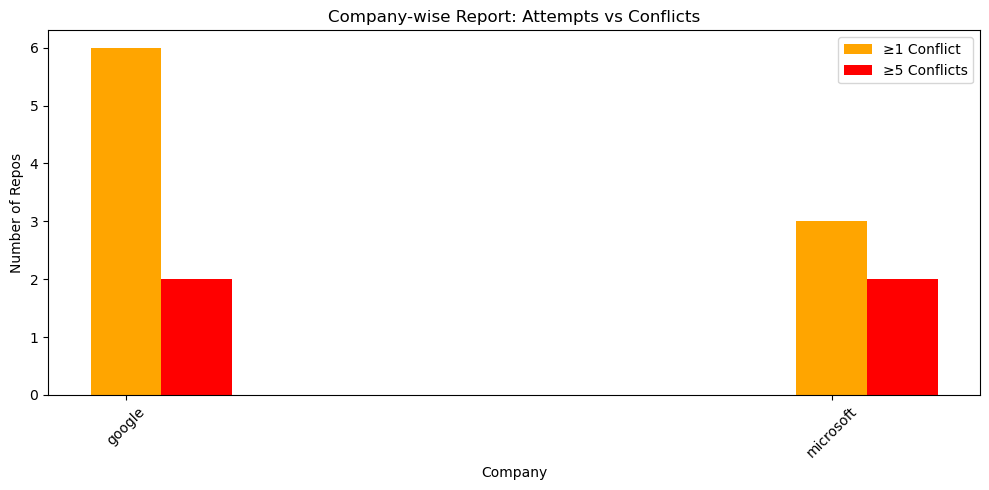

In [12]:
import matplotlib.pyplot as plt
from collections import defaultdict
from db_operations import get_db_conn

conn = get_db_conn()
cur = conn.cursor()

# Get processed repos per company (aka "attempts")
cur.execute("""
    SELECT LOWER(organization), COUNT(*) 
    FROM searchrepos 
    WHERE is_active = FALSE 
    GROUP BY LOWER(organization);
""")
company_attempts = {row[0]: row[1] for row in cur.fetchall()}

# Get all repos with conflicts >= 1
cur.execute("""
    SELECT LOWER(organization), COUNT(*), SUM(license_conflicts)
    FROM searchrepos
    WHERE is_active = FALSE AND license_conflicts >= 1
    GROUP BY LOWER(organization);
""")
company_conflict_1plus = {row[0]: row[1] for row in cur.fetchall()}
company_total_conflicts = {row[0]: row[2] for row in cur.fetchall()}

# Get all repos with conflicts >= 5
cur.execute("""
    SELECT LOWER(organization), COUNT(*)
    FROM searchrepos
    WHERE is_active = FALSE AND license_conflicts >= 5
    GROUP BY LOWER(organization);
""")
company_conflict_5plus = {row[0]: row[1] for row in cur.fetchall()}

cur.close()
conn.close()

# Aggregated counts
repos_1plus = sum(company_conflict_1plus.values())
repos_5plus = sum(company_conflict_5plus.values())
total_conflict_1plus = sum(company_total_conflicts.get(org, 0) for org in company_conflict_1plus)

# total_conflict_5plus isn't precomputed, but you can fetch that if needed separately.

# Print results
print(f"--- Conflict Report ---")
print(f"Repos with ≥1 conflict: {repos_1plus} | Total conflicts: {total_conflict_1plus}")
print(f"Repos with ≥5 conflicts: {repos_5plus}")

companies = sorted(set(company_attempts) | set(company_conflict_1plus) | set(company_conflict_5plus))

print(f"\n--- Company-wise Conflict Report ---")
for company in companies:
    attempts = company_attempts.get(company, 0)
    c1 = company_conflict_1plus.get(company, 0)
    c5 = company_conflict_5plus.get(company, 0)
    total_conflicts = company_total_conflicts.get(company, 0)
    print(f"{company}: Attempts (repos) = {attempts} | Repos with ≥1 conflict = {c1} | Repos with ≥5 conflicts = {c5} | Total conflicts = {total_conflicts}")

# Visualization
x = range(len(companies))
width = 0.1
repos_1plus_counts = [company_conflict_1plus.get(c, 0) for c in companies]
repos_5plus_counts = [company_conflict_5plus.get(c, 0) for c in companies]
attempt_counts = [company_attempts.get(c, 0) for c in companies]

plt.figure(figsize=(10, 5))
# plt.bar([i - width for i in x], attempt_counts, width=width, label='Attempts Made', color='gray')
plt.bar(x, repos_1plus_counts, width=width, label='≥1 Conflict', color='orange')
plt.bar([i + width for i in x], repos_5plus_counts, width=width, label='≥5 Conflicts', color='red')

plt.xlabel('Company')
plt.ylabel('Number of Repos')
plt.title('Company-wise Report: Attempts vs Conflicts')
plt.xticks(x, companies, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()